<a href="https://colab.research.google.com/github/SaiGanesh848/HPC/blob/main/HPC_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
%%writefile generate_log.py
import random

levels = ["INFO", "WARNING", "ERROR"]

num_logs = 5000

with open("log.txt", "w") as f:
    for i in range(num_logs):
        level = random.choice(levels)
        f.write(f"{level}: Sample log message {i}\n")

print("Log file generated successfully!")

Overwriting generate_log.py


In [32]:
!python generate_log.py

Log file generated successfully!


In [33]:
%%writefile log_analysis.c
#include <stdio.h>
#include <string.h>
#include <time.h>
#include <omp.h>

#define MAX 5000
#define LEN 200

char logs[MAX][LEN];

int main() {
    FILE *fp = fopen("log.txt", "r");

    if (!fp) {
        printf("Error: Cannot open log.txt\n");
        return 1;
    }

    int n = 0;
    while (fgets(logs[n], LEN, fp)) n++;
    fclose(fp);

    int error = 0, warn = 0, info = 0;

    // SERIAL
    clock_t s1 = clock();
    for (int i = 0; i < n; i++) {
        if (strstr(logs[i], "ERROR")) error++;
        if (strstr(logs[i], "WARNING")) warn++;
        if (strstr(logs[i], "INFO")) info++;
    }
    clock_t e1 = clock();
    double serial = (double)(e1 - s1) / CLOCKS_PER_SEC;

    // PARALLEL
    int error_p = 0, warn_p = 0, info_p = 0;
    double s2 = omp_get_wtime();

    #pragma omp parallel for reduction(+:error_p, warn_p, info_p)
    for (int i = 0; i < n; i++) {
        if (strstr(logs[i], "ERROR")) error_p++;
        if (strstr(logs[i], "WARNING")) warn_p++;
        if (strstr(logs[i], "INFO")) info_p++;
    }

    double e2 = omp_get_wtime();
    double parallel = e2 - s2;

    printf("Total Logs: %d\n\n", n);
    printf("Serial Time   = %.6f sec\n", serial);
    printf("Parallel Time = %.6f sec\n\n", parallel);

    printf("ERROR: %d\nWARNING: %d\nINFO: %d\n", error_p, warn_p, info_p);

    FILE *out = fopen("output.txt", "w");
    fprintf(out, "%.6f %.6f", serial, parallel);
    fclose(out);

    return 0;
}

Overwriting log_analysis.c


In [34]:
!gcc -fopenmp log_analysis.c -o log_analysis
!./log_analysis

Total Logs: 5000

Serial Time   = 0.000264 sec
Parallel Time = 0.000216 sec

ERROR: 1644
INFO: 1722


In [43]:
%%writefile gpu_log.cu
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <cuda.h>

#define MAX 5000
#define LEN 200

__global__ void countLogs(char *logs, int *error, int *warn, int *info, int n) {
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if (i >= n) return;

    int idx = i * LEN;
    char c = logs[idx];

    if (c == 'E') atomicAdd(error, 1);
    else if (c == 'W') atomicAdd(warn, 1);
    else if (c == 'I') atomicAdd(info, 1);
}

int main() {
    FILE *fp = fopen("log.txt", "r");

    if (!fp) {
        printf("Error: Cannot open log.txt\n");
        return 1;
    }

    static char logs[MAX][LEN];
    int n = 0;

    while (fgets(logs[n], LEN, fp)) n++;
    fclose(fp);

    char *flat = (char*)malloc(n * LEN);

    for (int i = 0; i < n; i++)
        memcpy(&flat[i * LEN], logs[i], LEN);

    char *d_logs;
    int *d_error, *d_warn, *d_info;

    int error = 0, warn = 0, info = 0;

    cudaMalloc(&d_logs, n * LEN);
    cudaMalloc(&d_error, sizeof(int));
    cudaMalloc(&d_warn, sizeof(int));
    cudaMalloc(&d_info, sizeof(int));

    cudaMemcpy(d_logs, flat, n * LEN, cudaMemcpyHostToDevice);
    cudaMemcpy(d_error, &error, sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_warn, &warn, sizeof(int), cudaMemcpyHostToDevice);
    cudaMemcpy(d_info, &info, sizeof(int), cudaMemcpyHostToDevice);

    int threads = 256;
    int blocks = (n + threads - 1) / threads;

    cudaEvent_t start, end;
    cudaEventCreate(&start);
    cudaEventCreate(&end);

    cudaEventRecord(start);

    countLogs<<<blocks, threads>>>(d_logs, d_error, d_warn, d_info, n);
    cudaDeviceSynchronize();

    cudaEventRecord(end);
    cudaEventSynchronize(end);

    float ms;
    cudaEventElapsedTime(&ms, start, end);

    float gpu_time = ms / 1000.0;

    cudaMemcpy(&error, d_error, sizeof(int), cudaMemcpyDeviceToHost);
    cudaMemcpy(&warn, d_warn, sizeof(int), cudaMemcpyDeviceToHost);
    cudaMemcpy(&info, d_info, sizeof(int), cudaMemcpyDeviceToHost);

    printf("Total Logs: %d\n\n", n);
    printf("ERROR: %d\nWARNING: %d\nINFO: %d\n\n", error, warn, info);
    printf("GPU Time: %.6f sec\n", gpu_time);

    FILE *g = fopen("gpu_output.txt", "w");
    fprintf(g, "%.6f", gpu_time);
    fclose(g);

    return 0;
}

Overwriting gpu_log.cu


In [44]:
!nvcc gpu_log.cu -o gpu_log
!./gpu_log

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Total Logs: 5000

ERROR: 1644
INFO: 1722

GPU Time: 0.000165 sec


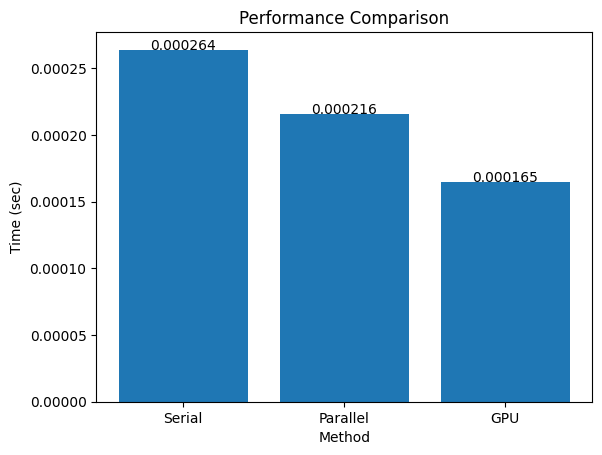

In [45]:
import matplotlib.pyplot as plt

with open("output.txt") as f:
    serial, parallel = map(float, f.read().split())

with open("gpu_output.txt") as f:
    gpu = float(f.read())

methods = ['Serial', 'Parallel', 'GPU']
times = [serial, parallel, gpu]

plt.figure()
plt.bar(methods, times)

for i, v in enumerate(times):
    plt.text(i, v, f"{v:.6f}", ha='center')

plt.title("Performance Comparison")
plt.ylabel("Time (sec)")
plt.xlabel("Method")

plt.savefig("performance comparison.png")
plt.show()